In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel("/Users/mitpatel/Desktop/CrimeRate-Prediction/data/crp.xlsx")

In [3]:
df.head()

,Year,City,Population (in Lakhs) (2011)+,Murder,Kidnapping,Crime against women,Crime against children,Crime Committed by Juveniles,Crime against Senior Citizen,Crime against SC,Crime against ST,Economic Offences,Cyber Crimes
0,2014,Ahmedabad,63.5,82,367,1371,437,215,68,66,6,399,32
1,2015,Ahmedabad,63.5,94,332,1067,609,157,17,60,9,378,28
2,2016,Ahmedabad,63.5,103,376,1126,481,258,362,96,10,479,77
3,2017,Ahmedabad,63.5,90,263,1405,600,405,534,119,6,608,112
4,2018,Ahmedabad,63.5,98,277,1416,733,352,733,145,9,842,212


In [4]:
df.tail()

,Year,City,Population (in Lakhs) (2011)+,Murder,Kidnapping,Crime against women,Crime against children,Crime Committed by Juveniles,Crime against Senior Citizen,Crime against SC,Crime against ST,Economic Offences,Cyber Crimes
147,2017,Surat,45.8,89,332,559,526,436,131,32,10,719,105
148,2018,Surat,45.8,108,373,712,1075,409,161,29,13,829,155
149,2019,Surat,45.8,97,358,1015,770,516,232,34,19,804,228
150,2020,Surat,45.8,116,163,633,419,298,69,20,12,401,204
151,2021,Surat,45.8,121,270,622,479,355,66,22,19,663,296


In [5]:
df.shape

(152, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           152 non-null    int64  
 1   City                           152 non-null    object 
 2   Population (in Lakhs) (2011)+  152 non-null    float64
 3   Murder                         152 non-null    int64  
 4   Kidnapping                     152 non-null    int64  
 5   Crime against women            152 non-null    int64  
 6   Crime against children         152 non-null    int64  
 7   Crime Committed by Juveniles   152 non-null    int64  
 8   Crime against Senior Citizen   152 non-null    int64  
 9   Crime against SC               152 non-null    int64  
 10  Crime against ST               152 non-null    int64  
 11  Economic Offences              152 non-null    int64  
 12  Cyber Crimes                   152 non-null    int

In [7]:
df.isnull().sum()

Year                             0
City                             0
Population (in Lakhs) (2011)+    0
Murder                           0
Kidnapping                       0
Crime against women              0
Crime against children           0
Crime Committed by Juveniles     0
Crime against Senior Citizen     0
Crime against SC                 0
Crime against ST                 0
Economic Offences                0
Cyber Crimes                     0
dtype: int64

In [8]:
df.nunique()

Year                               8
City                              19
Population (in Lakhs) (2011)+     19
Murder                           108
Kidnapping                       133
Crime against women              149
Crime against children           141
Crime Committed by Juveniles     119
Crime against Senior Citizen     110
Crime against SC                  95
Crime against ST                  31
Economic Offences                146
Cyber Crimes                     133
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#identifying garbage values
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print("***"*10)

City
Ahmedabad     8
Kochi         8
Pune          8
Patna         8
Nagpur        8
Mumbai        8
Lucknow       8
Kozhikode     8
Kolkata       8
Kanpur        8
Bengaluru     8
Jaipur        8
Indore        8
Hyderabad     8
Ghaziabad     8
Delhi         8
Coimbatore    8
Chennai       8
Surat         8
Name: count, dtype: int64
******************************


In [11]:
new_df = pd.DataFrame(columns=[
    'Year',
    'City',
    'Population (in Lakhs) (2011)+',
    'Number Of Cases',
    'Type'
])

In [12]:
for i in range(3, 13):

    temp = df[['Year', 'City', 'Population (in Lakhs) (2011)+']].copy()

    temp['Number Of Cases'] = df[df.columns[i]]

    temp['Type'] = df.columns[i]

    new_df = pd.concat([new_df, temp], ignore_index=True)

In [13]:
new_df.head()

,Year,City,Population (in Lakhs) (2011)+,Number Of Cases,Type
0,2014,Ahmedabad,63.5,82,Murder
1,2015,Ahmedabad,63.5,94,Murder
2,2016,Ahmedabad,63.5,103,Murder
3,2017,Ahmedabad,63.5,90,Murder
4,2018,Ahmedabad,63.5,98,Murder


In [14]:
new_df.tail()

,Year,City,Population (in Lakhs) (2011)+,Number Of Cases,Type
1515,2017,Surat,45.8,105,Cyber Crimes
1516,2018,Surat,45.8,155,Cyber Crimes
1517,2019,Surat,45.8,228,Cyber Crimes
1518,2020,Surat,45.8,204,Cyber Crimes
1519,2021,Surat,45.8,296,Cyber Crimes


In [15]:
new_df.shape

(1520, 5)

In [16]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           1520 non-null   object 
 1   City                           1520 non-null   object 
 2   Population (in Lakhs) (2011)+  1520 non-null   float64
 3   Number Of Cases                1520 non-null   object 
 4   Type                           1520 non-null   object 
dtypes: float64(1), object(4)
memory usage: 59.5+ KB


In [17]:
new_df['Number Of Cases']=new_df['Number Of Cases'].astype(int)

In [18]:
new_df['Year']=new_df['Year'].astype(int)

In [19]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           1520 non-null   int64  
 1   City                           1520 non-null   object 
 2   Population (in Lakhs) (2011)+  1520 non-null   float64
 3   Number Of Cases                1520 non-null   int64  
 4   Type                           1520 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 59.5+ KB


In [20]:
new_df.isnull().sum()

Year                             0
City                             0
Population (in Lakhs) (2011)+    0
Number Of Cases                  0
Type                             0
dtype: int64

In [21]:
new_df.nunique()

Year                               8
City                              19
Population (in Lakhs) (2011)+     19
Number Of Cases                  760
Type                              10
dtype: int64

In [22]:
new_df.duplicated().sum()

np.int64(0)

In [23]:
#identifying garbage values
for i in new_df.select_dtypes(include='object').columns:
    print(new_df[i].value_counts())
    print("***"*10)

City
Ahmedabad     80
Kochi         80
Pune          80
Patna         80
Nagpur        80
Mumbai        80
Lucknow       80
Kozhikode     80
Kolkata       80
Kanpur        80
Bengaluru     80
Jaipur        80
Indore        80
Hyderabad     80
Ghaziabad     80
Delhi         80
Coimbatore    80
Chennai       80
Surat         80
Name: count, dtype: int64
******************************
Type
Murder                          152
Kidnapping                      152
Crime against women             152
Crime against children          152
Crime Committed by Juveniles    152
Crime against Senior Citizen    152
Crime against SC                152
Crime against ST                152
Economic Offences               152
Cyber Crimes                    152
Name: count, dtype: int64
******************************


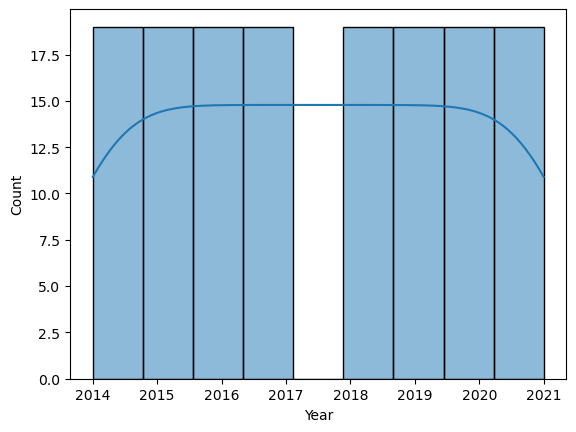

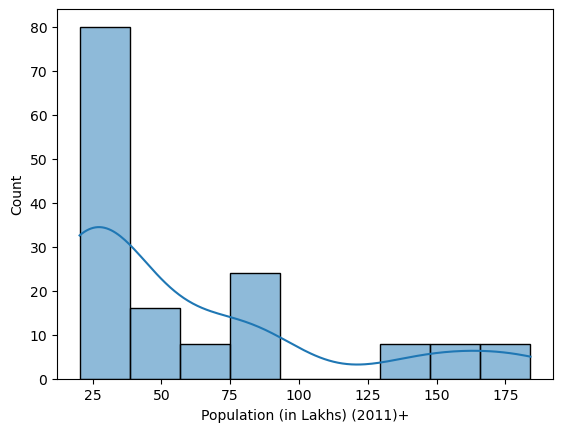

In [24]:
#histogram to understand distribution
for i in new_df.select_dtypes(include='number').columns:
    if i!='Number Of Cases':
     sns.histplot(df[i],kde=True)
     plt.show()

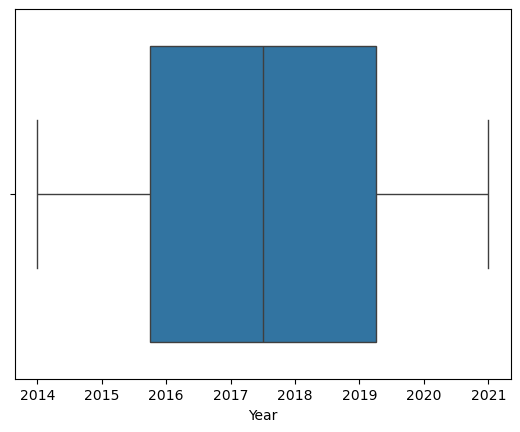

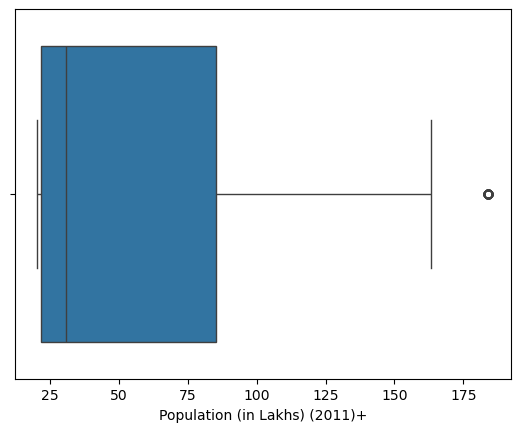

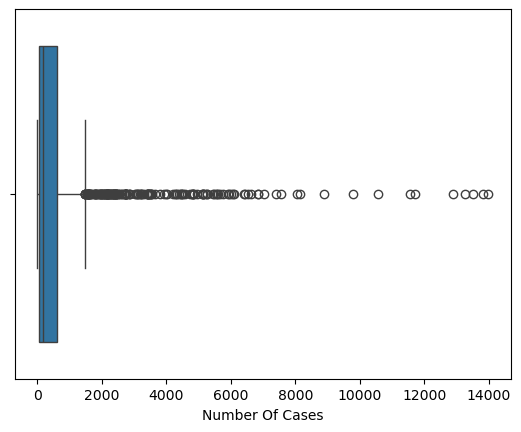

In [25]:
#Boxplot to identify outliers
for i in new_df.select_dtypes(include='number').columns:
    sns.boxplot(data=new_df,x=i)
    plt.show()

In [26]:
#corelation heatmap to interpret the realation and multicollinearity
s=new_df.select_dtypes(include='number').corr()

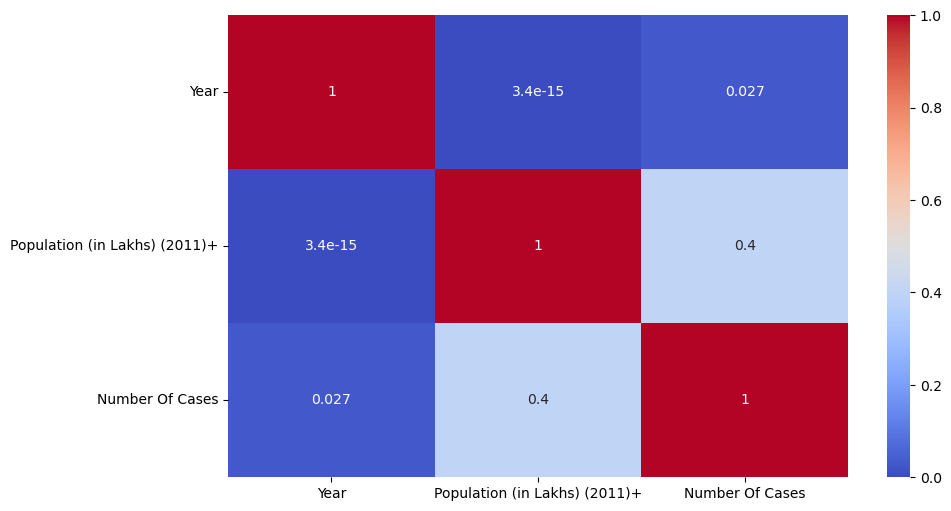

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(s,annot=True,cmap='coolwarm')
plt.show()

In [28]:
new_df.head()

,Year,City,Population (in Lakhs) (2011)+,Number Of Cases,Type
0,2014,Ahmedabad,63.5,82,Murder
1,2015,Ahmedabad,63.5,94,Murder
2,2016,Ahmedabad,63.5,103,Murder
3,2017,Ahmedabad,63.5,90,Murder
4,2018,Ahmedabad,63.5,98,Murder


<Axes: xlabel='City'>

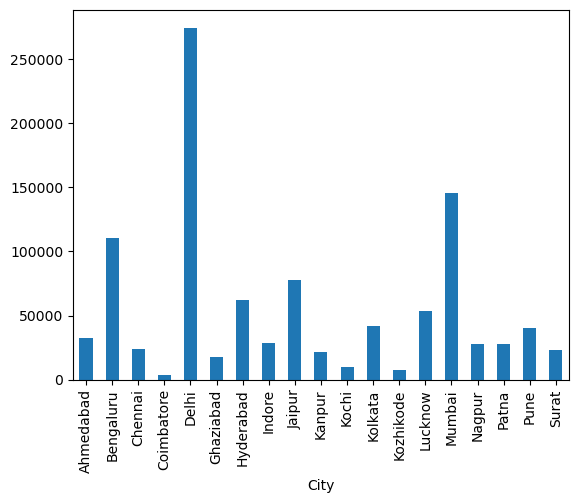

In [29]:
new_df.groupby('City')['Number Of Cases'].sum().plot(kind='bar')

In [30]:
ahmedabad_df = new_df[new_df['City'] == 'Ahmedabad']

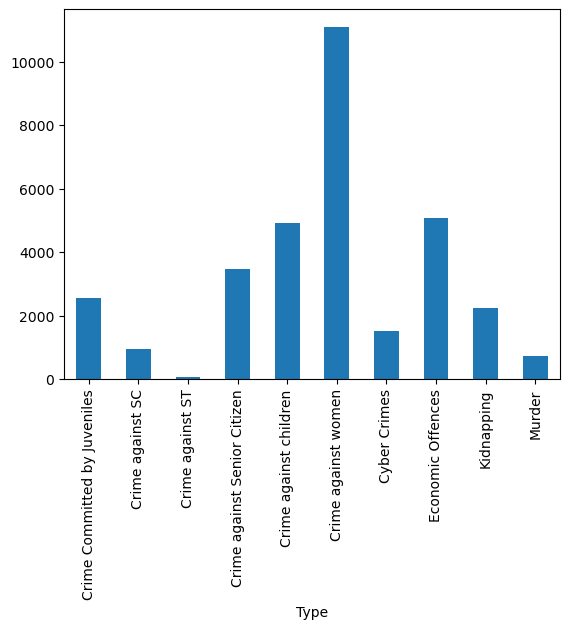

In [31]:
crime_summary = ahmedabad_df.groupby('Type')['Number Of Cases'].sum().plot(kind='bar')

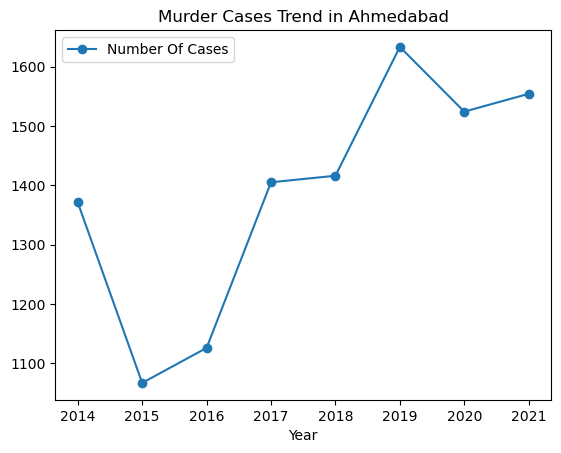

In [32]:
murder_df = new_df[(new_df['City'] == 'Ahmedabad') & (new_df['Type'] == 'Crime against women')]

murder_df.plot(x='Year', y='Number Of Cases', kind='line', marker='o')
plt.title("Murder Cases Trend in Ahmedabad")
plt.show()

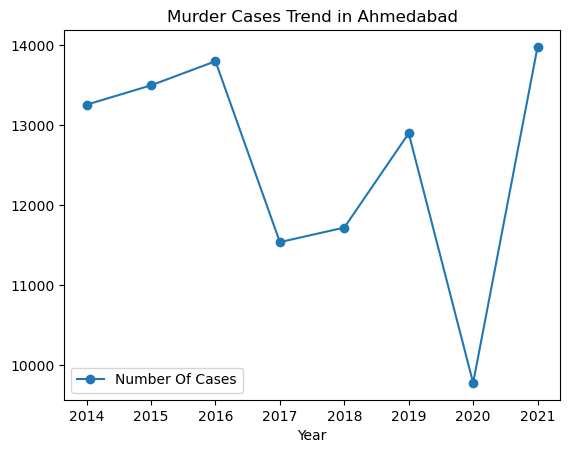

In [33]:
murder_df = new_df[(new_df['City'] == 'Delhi') & (new_df['Type'] == 'Crime against women')]

murder_df.plot(x='Year', y='Number Of Cases', kind='line', marker='o')
plt.title("Murder Cases Trend in Ahmedabad")
plt.show()

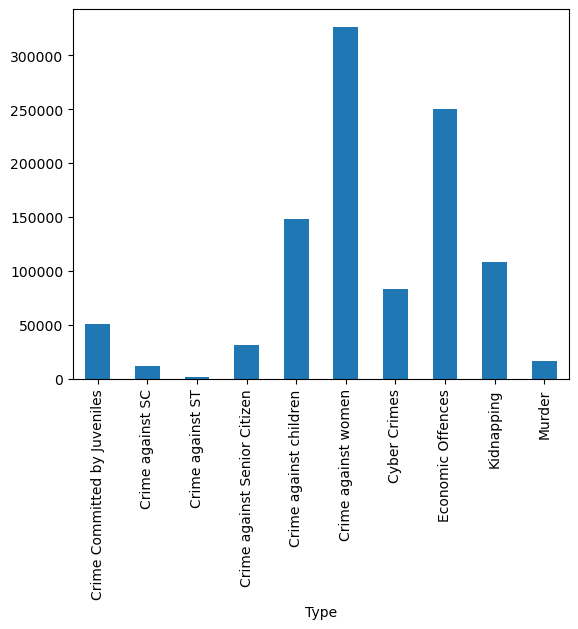

In [85]:
crime_type = new_df.groupby('Type')['Number Of Cases'].sum().plot(kind='bar')

In [37]:
new_df.groupby('Type')['Number Of Cases'].sum()

Type
Crime Committed by Juveniles     51182
Crime against SC                 12287
Crime against ST                  1448
Crime against Senior Citizen     31272
Crime against children          148155
Crime against women             326424
Cyber Crimes                     83629
Economic Offences               249962
Kidnapping                      108833
Murder                           16452
Name: Number Of Cases, dtype: int64

In [38]:
new_df.to_csv("/Users/mitpatel/Desktop/CrimeRate-Prediction/data/final_df.csv",index=False)